# Attention Residuals 注意力残差聚合实现

## 一、环境导入

In [2]:
import torch  # 导入PyTorch核心库，用于张量操作和自动微分
import torch.nn as nn  # 导入神经网络模块，提供Module/Parameter/Linear等基础组件
import torch.nn.functional as F  # 导入函数式API，提供softmax/silu等无状态函数
import matplotlib.pyplot as plt  # 导入matplotlib绘图库，用于可视化注意力权重分布
from typing import Optional, List  # 导入类型注解：Optional用于可选参数，List用于列表参数

## 二、Full AttnRes 全注意力残差块

In [3]:
class FullAttnResBlock(nn.Module):
    """
    完整注意力残差块 | 对应论文 Section 3.1 Equation 1/2/3
    核心：每层通过可学习伪查询对前序层输出做注意力加权聚合
    Args:
        dim: int 隐藏层特征维度
        num_layers: int 模型总层数（决定伪查询参数个数）
    """
    def __init__(self, dim: int, num_layers: int):
        super().__init__()  # 调用父类 nn.Module 的初始化方法
        self.dim = dim  # 隐藏层维度，int
        self.num_layers = num_layers  # 模型总层数，int
        
        # 每层一个可学习伪查询 q_l = w_l (论文 Equation 3)，形状 [num_layers, dim]
        self.queries = nn.Parameter(torch.randn(num_layers, dim))
        # 论文指定使用RMSNorm，而非LayerNorm，对键向量做归一化
        self.norm = nn.RMSNorm(dim)
        # 温度参数：稳定训练，防止注意力分布过于集中，初始值0.1，形状 [1]
        self.temperature = nn.Parameter(torch.ones(1) * 0.1)

    def forward(self, layer_outputs: torch.Tensor, current_layer: int) -> tuple[torch.Tensor, torch.Tensor]:
        """
        前向传播：对前序所有层的输出做注意力加权聚合
        Args:
            layer_outputs: torch.Tensor [batch, num_previous_layers, dim] 前序所有层的输出
            current_layer: int 当前层的索引（从0开始），用于选取对应伪查询
        Returns:
            aggregated: torch.Tensor [batch, dim] 注意力加权聚合后的特征
            attn_weights: torch.Tensor [batch, num_previous_layers] 注意力权重（每行和为1）
        """
        # 1. 获取当前层的伪查询，扩展维度适配批量计算；形状 [1, 1, dim]
        q = self.queries[current_layer].unsqueeze(0).unsqueeze(1)  # [1, 1, dim]
        # 2. 前序层输出做RMSNorm归一化，作为键向量；形状 [batch, num_previous_layers, dim]
        k = self.norm(layer_outputs)  # [batch, num_previous_layers, dim]
        # 3. 点积计算注意力分数，除以温度缩放（论文 Equation 2）；形状 [batch, num_previous_layers]
        scores = torch.sum(q * k, dim=-1) / self.temperature  # [batch, num_previous_layers]
        # softmax归一化，得到各前序层的注意力权重；形状 [batch, num_previous_layers]
        attn_weights = F.softmax(scores, dim=-1)  # [batch, num_previous_layers]
        # 4. 加权聚合前序层输出（论文 Equation 1）；形状 [batch, dim]
        aggregated = torch.sum(attn_weights.unsqueeze(-1) * layer_outputs, dim=1)  # [batch, dim]
        
        return aggregated, attn_weights  # 返回聚合特征 [batch, dim] 和注意力权重 [batch, num_previous_layers]


class AttnResLayer(nn.Module):
    """
    集成Full AttnRes的完整层：注意力残差聚合 + MLP特征变换
    Args:
        dim: int 隐藏层特征维度
        num_layers: int 总层数，传入 FullAttnResBlock 用于初始化伪查询
        mlp_ratio: float MLP升维倍率，默认4.0
    """
    def __init__(self, dim: int, num_layers: int, mlp_ratio: float = 4.0):
        super().__init__()  # 调用父类 nn.Module 的初始化方法
        self.attn_res = FullAttnResBlock(dim, num_layers)  # 注意力残差聚合块，负责跨层特征融合
        # MLP层：经典GELU激活，维度先升后降（升维比例由mlp_ratio决定）
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),  # 升维线性变换，输出维度 dim*mlp_ratio
            nn.GELU(),                              # GELU激活函数，平滑非线性变换
            nn.Linear(int(dim * mlp_ratio), dim)   # 降维线性变换，还原为 dim 维度
        )
        self.norm = nn.RMSNorm(dim)  # RMSNorm归一化，在MLP输入前使用，稳定训练

    def forward(self, layer_outputs: torch.Tensor, current_layer: int) -> tuple[torch.Tensor, torch.Tensor]:
        """
        前向传播：先做注意力残差聚合，再经MLP变换
        Args:
            layer_outputs: torch.Tensor [batch, num_previous_layers, dim] 前序所有层的输出
            current_layer: int 当前层的索引，传递给 FullAttnResBlock 选取对应伪查询
        Returns:
            output: torch.Tensor [batch, dim] MLP变换后的输出特征
            attn_weights: torch.Tensor [batch, num_previous_layers] 注意力权重
        """
        # 注意力残差聚合，返回聚合特征 [batch, dim] 和权重 [batch, num_previous_layers]
        aggregated, attn_weights = self.attn_res(layer_outputs, current_layer)
        # 先对聚合特征做RMSNorm归一化，再经MLP变换；输出形状 [batch, dim]
        output = self.mlp(self.norm(aggregated))
        return output, attn_weights  # 返回MLP输出 [batch, dim] 和注意力权重 [batch, num_previous_layers]

## 三、Block AttnRes 分块注意力残差块

In [ ]:
class BlockAttnRes(nn.Module):
    """
    分块注意力残差块 | 对应论文 Section 3.2 Equation 4
    核心：分块降低计算/存储开销，兼顾性能与效率
    """
    def __init__(self, dim: int, num_layers: int, num_blocks: int = 4):
        super().__init__()  # 调用父类初始化方法
        self.dim = dim  # 每层特征维度
        self.num_layers = num_layers  # 总层数
        self.num_blocks = num_blocks  # 块数，将层等分为若干块
        self.layers_per_block = num_layers // num_blocks  # 每块的层数（要求num_layers能被num_blocks整除）
        
        # 每块一个可学习伪查询（作为attention的query），用于块间融合
        self.block_queries = nn.Parameter(torch.randn(num_blocks, dim))
        self.norm = nn.RMSNorm(dim)  # 块间RMSNorm归一化
        self.temperature = nn.Parameter(torch.ones(1) * 0.1)  # 温度参数，用于缩放attention分数

    def forward(self, all_layer_outputs: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            all_layer_outputs: [batch, num_layers, dim] 模型所有层的输出
        Returns:
            aggregated: [batch, dim] 块间注意力聚合后的特征
            block_attn_weights: [batch, num_blocks] 块级注意力权重
        """
        batch_size = all_layer_outputs.shape[0]  # 获取batch大小
        blocks = []  # 保存各个块的聚合结果
        # 1. 块内标准残差累积（论文 Equation 4）
        for n in range(self.num_blocks):  # 遍历所有块
            start = n * self.layers_per_block  # 当前块的起始层index
            end = (n + 1) * self.layers_per_block  # 当前块的结束层index
            # 块内所有层输出在维度1（即层之间）求和（实现“标准残差”）
            block_sum = torch.sum(all_layer_outputs[:, start:end, :], dim=1)  # [batch, dim]
            blocks.append(block_sum)  # 添加进blocks
        blocks = torch.stack(blocks, dim=1)  # 堆叠所有块，得到[batch, num_blocks, dim]
        
        # 2. 块间注意力聚合（同Full AttnRes逻辑）
        q = self.block_queries.unsqueeze(0)  # 扩展batch维度，形状[1, num_blocks, dim]
        k = self.norm(blocks)  # 块特征做RMSNorm归一化，[batch, num_blocks, dim]
        scores = torch.sum(q * k, dim=-1) / self.temperature  # 计算注意力分数并缩放 [batch, num_blocks]
        block_attn_weights = F.softmax(scores, dim=-1)  # softmax归一化，得到权重 [batch, num_blocks]
        aggregated = torch.sum(block_attn_weights.unsqueeze(-1) * blocks, dim=1)  # 加权聚合 [batch, dim]
        
        return aggregated, block_attn_weights  # 返回聚合特征和权重


class BlockAttnResTransformer(nn.Module):
    """
    使用Block AttnRes的完整Transformer模型 | 端到端可训练
    核心：将分块注意力残差聚合嵌入标准Transformer架构，兼顾性能与效率
    Args:
        vocab_size: int 词表大小，决定嵌入层和输出头的维度
        dim: int 隐藏层特征维度
        num_layers: int Transformer层数，同时也是BlockAttnRes的总层数
        num_blocks: int 分块数量，默认4
        mlp_ratio: float MLP升维倍率，默认4.0
    """
    def __init__(self, vocab_size: int, dim: int, num_layers: int, num_blocks: int = 4, mlp_ratio: float = 4.0):
        super().__init__()  # 调用父类 nn.Module 的初始化方法
        self.embedding = nn.Embedding(vocab_size, dim)  # 词嵌入层：将 token id 映射为特征向量，输出 [batch, seq_len, dim]
        # 堆叠 num_layers 个 BlockAttnRes 块，每层共享相同超参，用 ModuleList 管理
        self.attn_res_blocks = nn.ModuleList([
            BlockAttnRes(dim, num_layers, num_blocks)  # 每个块：分块注意力残差聚合，输入所有层输出
            for _ in range(num_layers)                 # 共 num_layers 层
        ])
        self.mlp = nn.Sequential(                        # 共享 MLP 层，对每层聚合特征做非线性变换
            nn.Linear(dim, int(dim * mlp_ratio)),        # 升维线性变换，输出维度 dim*mlp_ratio
            nn.GELU(),                                   # GELU激活函数，平滑非线性变换
            nn.Linear(int(dim * mlp_ratio), dim)         # 降维线性变换，还原为 dim 维度
        )
        self.norm = nn.RMSNorm(dim)  # 输出特征归一化，用于最终头部输入前的归一化
        self.head = nn.Linear(dim, vocab_size)  # 输出头：将特征维度映射到词表大小，用于下一个 token 预测

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: [batch, seq_len] 输入token序列
        Returns:
            logits: [batch, seq_len, vocab_size] 词表预测概率
        """
        h = self.embedding(x)  # 输入进行词嵌入 [batch, seq_len, dim]
        all_outputs = []  # 用于存储每层输出
        for block in self.attn_res_blocks:  # 依次通过每一层BlockAttnRes
            all_outputs.append(h)  # 记录每层输出
            all_outputs_tensor = torch.stack(all_outputs, dim=1)  # 堆叠过往所有输出 [batch, num_layers, dim]
            # 块注意力残差聚合，得到聚合后的特征
            aggregated, _ = block(all_outputs_tensor)
            # MLP特征变换：归一化后通过MLP
            h = self.mlp(self.norm(aggregated))
        # 输出层：先归一化后线性变换，得到最终预测logits
        logits = self.head(self.norm(h))
        return logits  # 返回词表预测logits

## 四、集成 Attention Residuals 的标准 Transformer 层

In [5]:
class AttnResTransformerLayer(nn.Module):
    """
    集成Attention Residuals的标准Transformer层
    核心：自注意力 + AttnRes聚合 双特征融合，兼容原始Transformer残差结构
    Args:
        dim: int 隐藏层特征维度
        num_heads: int 多头自注意力的头数
        num_previous_layers: int 前序层的数量，用于初始化 FullAttnResBlock 伪查询
    """
    def __init__(self, dim: int, num_heads: int, num_previous_layers: int):
        super().__init__()  # 调用父类 nn.Module 的初始化方法
        # 标准多头自注意力，batch_first=True 表示输入形状为 [batch, seq_len, dim]
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        # 经典MLP层：升维后激活再降维，进行非线性特征变换
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),  # 升维线性变换，输出维度 dim*4
            nn.GELU(),                # GELU激活函数，平滑非线性变换
            nn.Linear(dim * 4, dim)   # 降维线性变换，还原为 dim 维度
        )
        # 传统LayerNorm（适配原有Transformer），用于自注意力输出的归一化
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)  # 用于MLP输入前的归一化，与norm1独立
        # 添加Full AttnRes块，负责对前序所有层做注意力聚合
        self.attn_res = FullAttnResBlock(dim, num_previous_layers)

    def forward(self, x: torch.Tensor, all_previous_outputs: List[torch.Tensor]) -> tuple[torch.Tensor, torch.Tensor]:
        """
        前向传播：自注意力与跨层AttnRes双路融合
        Args:
            x: torch.Tensor [batch, seq_len, dim] 当前层输入特征
            all_previous_outputs: List[torch.Tensor] 前序所有层的输出列表，每个元素形状 [batch, dim]
        Returns:
            x: torch.Tensor [batch, seq_len, dim] 融合后的输出特征
            attn_weights: torch.Tensor [batch, num_previous_layers] AttnRes的注意力权重
        """
        # 标准多头自注意力计算，Q=K=V=x（自注意力）；attn_out形状 [batch, seq_len, dim]
        attn_out, _ = self.attn(x, x, x)
        # 堆叠前序层输出为张量，适配AttnRes输入格式；形状 [batch, num_previous_layers, dim]
        all_outputs = torch.stack(all_previous_outputs, dim=1)  # [batch, num_previous_layers, dim]
        # AttnRes聚合前序层特征；aggregated形状 [batch, dim]，attn_weights形状 [batch, num_previous_layers]
        aggregated, attn_weights = self.attn_res(all_outputs, current_layer=-1)
        # 融合自注意力特征 + AttnRes聚合特征（残差连接）；unsqueeze扩展seq_len维度适配广播
        x = x + self.norm1(attn_out) + aggregated.unsqueeze(1)  # [batch, seq_len, dim]
        # MLP层残差连接：先归一化再变换后与x相加；形状保持 [batch, seq_len, dim]
        x = x + self.mlp(self.norm2(x))
        return x, attn_weights  # 返回融合输出 [batch, seq_len, dim] 和注意力权重 [batch, num_previous_layers]

## 五、单元测试：验证 Full AttnRes 形状与权重正确性

In [6]:
def test_full_attn_res():
    """
    测试 FullAttnResBlock 的基本功能：形状验证 + 注意力权重和为1
    验证内容：
        1. 聚合特征形状是否为 [batch_size, dim]
        2. 注意力权重形状是否为 [batch_size, num_previous_layers]
        3. 注意力权重每行之和是否等于1（softmax正确性）
    """
    batch_size = 4   # 批大小，int，模拟4个样本并行推理
    num_layers = 10  # 总层数，int，模型共10层
    dim = 512        # 特征维度，int，每层输出512维向量
    # 初始化 FullAttnResBlock 模型，使用上方定义的超参
    model = FullAttnResBlock(dim, num_layers)
    # 模拟前9层的输出（current_layer=9时，前序共9层），形状 [batch_size, num_layers-1, dim]
    layer_outputs = torch.randn(batch_size, num_layers - 1, dim)
    # 前向传播，aggregated: [batch_size, dim]，attn_weights: [batch_size, num_layers-1]
    aggregated, attn_weights = model(layer_outputs, current_layer=9)
    # 形状验证：聚合特征应为 [batch_size, dim]
    assert aggregated.shape == (batch_size, dim), "聚合特征形状错误"
    # 形状验证：注意力权重应为 [batch_size, num_previous_layers]
    assert attn_weights.shape == (batch_size, num_layers - 1), "注意力权重形状错误"
    # 注意力权重和为1验证：每个样本的权重之和应等于1（softmax性质）
    assert torch.allclose(attn_weights.sum(dim=-1), torch.ones(batch_size)), "注意力权重和不为1"
    print("✅ Full AttnRes 单元测试通过！")  # 所有断言通过，打印成功提示

# 运行测试函数，验证 FullAttnResBlock 的正确性
test_full_attn_res()

✅ Full AttnRes 单元测试通过！


## 六、注意力权重可视化

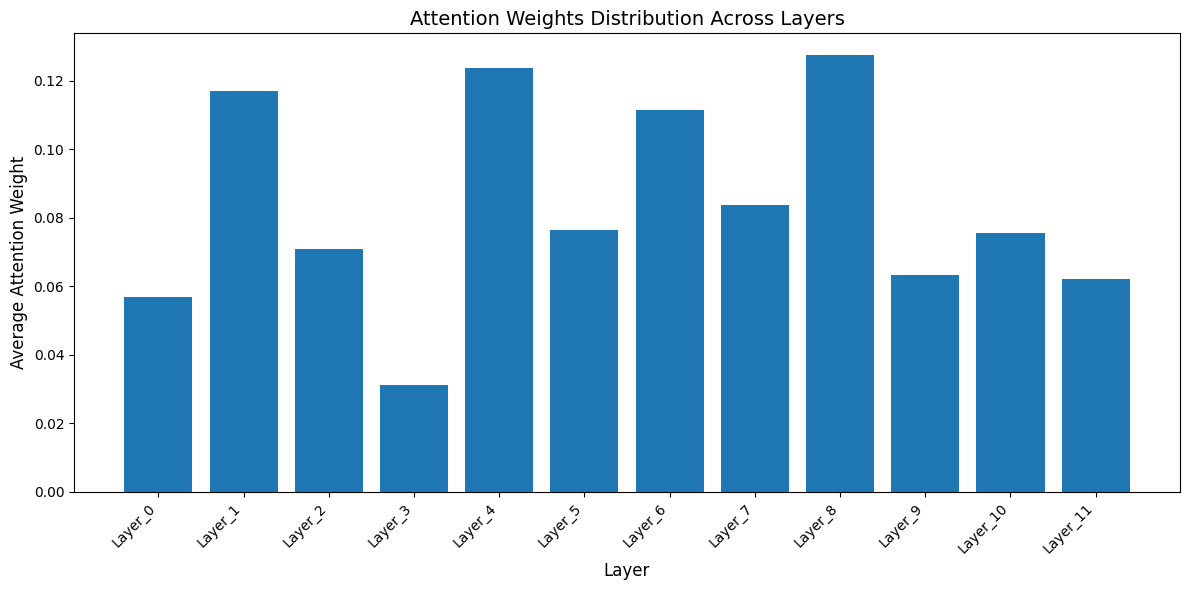

📊 注意力权重可视化结果已保存至 attn_weights.png


In [7]:
def visualize_attn_weights(attn_weights: torch.Tensor, layer_names: List[str], save_path: str = "attn_weights.png"):
    """
    可视化注意力权重分布 | 对应论文 Figure 3
    Args:
        attn_weights: torch.Tensor [batch, num_layers] 注意力权重张量，每行之和为1
        layer_names: List[str] 层名称列表，长度等于 num_layers，如 ['Layer_0', 'Layer_1', ...]
        save_path: str 可视化图片保存路径，默认 "attn_weights.png"
    Returns:
        None（副作用：保存PNG图片并显示）
    """
    # 对 batch 维度求均值，得到跨样本的平均注意力权重；形状从 [batch, num_layers] 降为 [num_layers]
    avg_weights = attn_weights.mean(dim=0).cpu().numpy()  # numpy数组，形状 [num_layers]
    # 创建画布，宽12英寸、高6英寸，适配较多层数的横向展示
    plt.figure(figsize=(12, 6))
    # 绘制蓝色柱状图，x轴为层名称，y轴为平均权重值
    plt.bar(layer_names, avg_weights, color="#1f77b4")
    # 旋转x轴标签45°并右对齐，防止层名称重叠
    plt.xticks(rotation=45, ha="right")
    # 设置图表标题，字体大小14
    plt.title("Attention Weights Distribution Across Layers", fontsize=14)
    # 设置x轴标签
    plt.xlabel("Layer", fontsize=12)
    # 设置y轴标签
    plt.ylabel("Average Attention Weight", fontsize=12)
    plt.tight_layout()  # 自动调整子图参数，防止标签被截断
    # 保存图片到指定路径，分辨率300 dpi（适合论文/报告质量）
    plt.savefig(save_path, dpi=300)
    plt.show()  # 在 notebook 中内联显示图表
    print(f"📊 注意力权重可视化结果已保存至 {save_path}")  # 提示保存路径

# 可视化使用示例（仅在直接运行脚本时执行，notebook中 __name__ == "__main__" 始终为真）
if __name__ == "__main__":
    # 模拟注意力权重：随机初始化，batch=8，共12层
    fake_attn_weights = torch.randn(8, 12)
    # 对每个样本做 softmax，模拟真实的归一化注意力权重；形状 [8, 12]
    fake_attn_weights = F.softmax(fake_attn_weights, dim=-1)
    # 生成12个层的名称列表，如 ['Layer_0', ..., 'Layer_11']
    layer_names = [f"Layer_{i}" for i in range(12)]
    # 调用可视化函数，绘制并保存注意力权重分布图
    visualize_attn_weights(fake_attn_weights, layer_names)